In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
file="/kaggle/input/netflix-shows/netflix_titles.csv"
df=pd.read_csv(file)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/netflix-shows/netflix_titles.csv


Understanding Dataset

In [2]:
print('size of dataframe\n',df.shape,'\n')
print('list of columns')
print(list(df.columns),'\n')
print('datatype of each column')
for i in list(df.columns):
    print(df[i].dtype)
print('\n')
print('columns with number of null values')
print(df.isnull().sum())

size of dataframe
 (8807, 12) 

list of columns
['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added', 'release_year', 'rating', 'duration', 'listed_in', 'description'] 

datatype of each column
object
object
object
object
object
object
object
int64
object
object
object
object


columns with number of null values
show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64


General Insights 

total content  8807
number of movies 6131
number of TV shows  2676
latest movie on netflix Blood & Water on 2021
oldest movie on netflix Pioneers: First Women Filmmakers* on 1925
top countries with most publishes
country
United States     2818
India              972
United Kingdom     419
Japan              245
South Korea        199
Canada             181
Spain              145
France             124
Mexico             110
Egypt              106
Name: count, dtype: int64
top 5 high publishing directors
director
Rajiv Chilaka             19
Raúl Campos, Jan Suter    18
Marcus Raboy              16
Suhas Kadav               16
Jay Karas                 14
Name: count, dtype: int64


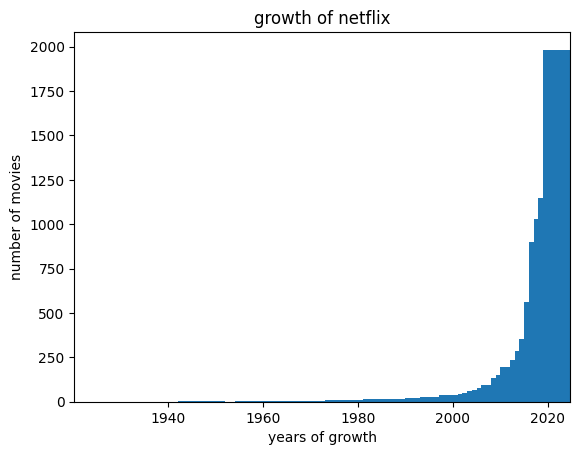

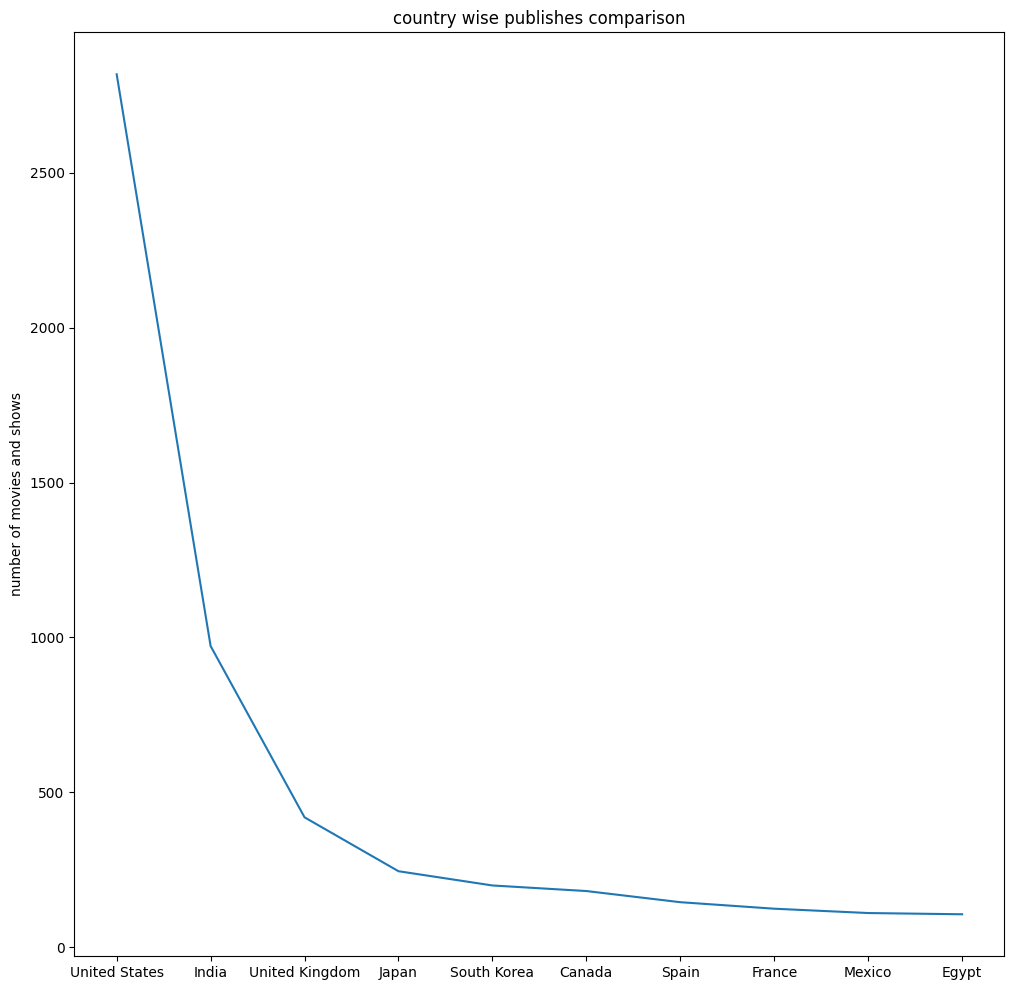

In [3]:
print('total content ',df['title'].count())
print('number of movies' ,(df['type']=='Movie').sum())
print('number of TV shows ',(df['type']=='TV Show').sum())
oldest=df.loc[df['release_year'].idxmin()]
latest=df.loc[df['release_year'].idxmax()]
print('latest movie on netflix',latest['title'],'on',latest['release_year'])
print('oldest movie on netflix',oldest['title'],'on',oldest['release_year'])
plt.hist(df['release_year'],bins=np.arange(1925,2021,1),width=6)
plt.xlabel('years of growth')
plt.ylabel('number of movies')
plt.title('growth of netflix')
country_counts = df['country'].value_counts()
directorslist= df['director'].value_counts()
print('top countries with most publishes')
print(country_counts.head(10))
print('top 5 high publishing directors')
print(directorslist.head(5))
plt.figure(figsize=(12,12))
plt.title('country wise publishes comparison')
plt.ylabel('number of movies and shows')
country_counts2=country_counts.head(10)
plt.plot(country_counts2.index,country_counts2.values)

Time Based Analysis****

top 5 years with most release
release_year
2018    1147
2017    1032
2019    1030
2020     953
2016     902
Name: count, dtype: int64
movies and shows per year
type          Movie  TV Show
release_year                
1925            0.0      1.0
1942            2.0      0.0
1943            3.0      0.0
1944            3.0      0.0
1945            3.0      1.0
...             ...      ...
2017          767.0    265.0
2018          767.0    380.0
2019          633.0    397.0
2020          517.0    436.0
2021          277.0    315.0

[74 rows x 2 columns]


<BarContainer object of 74 artists>

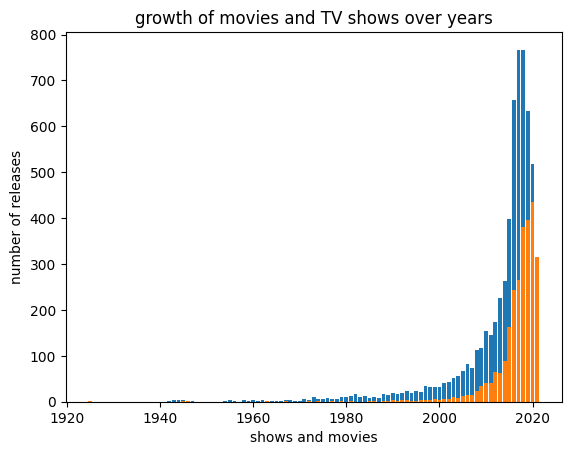

In [4]:
moviesperyear=df['release_year'].value_counts()
print('top 5 years with most release')
print(moviesperyear.head(5))
trend=df.groupby(['release_year','type']).size().reset_index(name='count')
trendanalysis=trend.pivot(index='release_year',columns='type',values='count').fillna(0)
print('movies and shows per year')
print(trendanalysis)
plt.title('growth of movies and TV shows over years')
plt.xlabel('shows and movies')
plt.ylabel('number of releases')
plt.bar(trendanalysis.index,trendanalysis['Movie'])
plt.bar(trendanalysis.index,trendanalysis['TV Show'])


Duration Analysis

In [5]:
print('average duration of movies')
movies = df[df['type'] == 'Movie'].copy()
movies['duration']=movies['duration'].fillna('0 min')
movies['duration_min']=movies['duration'].str.replace(' min','').astype(int)
print(movies['duration_min'].mean(),'mins')
print('most common duration')
print(movies['duration_min'].value_counts().head(1))
show = df[df['type'] == 'TV Show'].copy()
show['duration']=show['duration'].fillna('0 season')
print('number of season for each show')
print(show['duration'].value_counts())


average duration of movies
99.52846191485891 mins
most common duration
duration_min
90    152
Name: count, dtype: int64
number of season for each show
duration
1 Season      1793
2 Seasons      425
3 Seasons      199
4 Seasons       95
5 Seasons       65
6 Seasons       33
7 Seasons       23
8 Seasons       17
9 Seasons        9
10 Seasons       7
13 Seasons       3
15 Seasons       2
12 Seasons       2
11 Seasons       2
17 Seasons       1
Name: count, dtype: int64


Global and regional trend

In [6]:
print('Top 5 countries with most number of release ')
print(df['country'].value_counts().head(5))


Top 5 countries with most number of release 
country
United States     2818
India              972
United Kingdom     419
Japan              245
South Korea        199
Name: count, dtype: int64
